# Partial Dependence Plot: EPS vs Analysts' Forecasts

This notebook reproduces the figure "EPS as a non-Linear function of analysts' forecasts" using a Random Forest model. We analyze the relationship between Realized EPS and Analysts' Forecasts.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn import preprocessing
from tqdm.auto import tqdm
from functions import read_merge_prepare_data, PrepareMacro

%matplotlib inline

## 1. Load Data
We load the macro data and the processed dataset for the chosen period (e.g., A1, Q1). The figure description mentions "one-quarter-ahead realized EPS", which corresponds to `Q1`. However, we can easily switch between periods.

In [6]:
# Load Macro Data
macro_file_path = "data/processed_data/macro_data.csv"
Macro_Data = pd.read_csv(macro_file_path)

# Choose period (e.g., 'A1' or 'Q1' based on what you want to visualize)
# The figure suggests examining the non-linear relationship.
# Let's start with 'Q1' (quarterly forecast) as it's common.
forecast_period = 'Q1'

# Load and Prepare the Dataset
df = read_merge_prepare_data(forecast_period, Macro_Data)

print(f"Data Loaded: {len(df)} rows")
df.head()

Q1 Missing Values:
price              17
ret                19
capei           41209
be              41209
bm              41209
                ...  
mktcap          41209
ptb             41209
peg_trailing    41209
divyield        41209
ffi49           41209
Length: 72, dtype: int64
Data Loaded: 887766 rows
Data Loaded: 887766 rows


,permno,price,ret,meanest,numest,adj_actual,adj_past_eps,capei,be,bm,...,mktcap,ptb,peg_trailing,divyield,ffi49,GDP_log_return,Cons_log_return,IPT_log_return,Unempl,Date
0,63386,11.75,-0.020833,0.35,1.0,0.3500,0.1100,19.871881,37.578,0.228598,...,90.65000,2.412316,0.080192,0.023063,34.0,0.009618,0.009617,0.002404,7.3,1985-02
36,62682,21.00,-0.011765,0.23,1.0,0.2752,0.1664,20.215607,84.282,0.682454,...,115.63125,1.371957,2.807512,0.022857,42.0,0.002225,-0.000744,-0.011470,7.3,1985-03
37,35051,37.00,0.000000,0.10,1.0,0.0800,0.0700,27.878042,156.685,0.233269,...,689.87700,4.402955,3.173548,0.012549,21.0,0.002225,-0.000744,-0.011470,7.3,1985-03
38,55976,45.25,0.008357,0.00,3.0,0.0039,0.0079,56.462495,902.158,0.152798,...,6380.10100,7.072044,0.438309,0.004659,43.0,0.002225,-0.000744,-0.011470,7.3,1985-03
40,13777,18.00,0.000000,0.06,1.0,0.0978,0.0790,14.874196,28.160,0.464975,...,46.87500,1.664595,0.508065,0.021622,34.0,0.002225,-0.000744,-0.011470,7.3,1985-03


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn import preprocessing
from scipy.stats.mstats import winsorize

# ==========================================
# 1. 数据预处理 (加入 Winsorization)
# ==========================================

# 复制数据以防修改原件
X = df.drop(columns=['adj_actual', 'Date', 'permno', 'numest']).copy()
y = df['adj_actual'].copy()

# 论文脚注15: "winsorize the forecasting variables at the 1% level"
# 对每一列特征进行 1% 的双边缩尾处理
for col in X.columns:
    X[col] = winsorize(X[col], limits=[0.01, 0.01])

# 论文: "and standardize them"
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
# 将 numpy array 转回 DataFrame 以便保留列名，这对 PDP 很重要
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

meanest_idx = X.columns.get_loc('meanest')
print(f"'meanest' feature is at index: {meanest_idx}")

# ==========================================
# 2. 模型训练 (调整超参数以匹配 Table 1)
# ==========================================

# 论文 Table 1 参数:
# Number of Trees: 2000
# Maximum Depth: 7  <-- 关键！限制深度能让曲线更平滑
# Sample Fraction: 1% (0.01)
# Minimum Node Size: 5 (虽然Figure 1 caption说是1，但为了平滑建议设为5或保持1配合depth限制)

rf_model = RandomForestRegressor(
    n_estimators=2000,      
    max_depth=7,             # 限制深度，防止过拟合，使曲线平滑
    min_samples_leaf=1,      # 照应 Figure 1 caption
    max_samples=0.01,        # 照应 Table 1 (1%)
    max_features='sqrt', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

print("Training Random Forest with Paper Parameters...")
rf_model.fit(X_scaled, y)
print("Training Complete.")

'meanest' feature is at index: 2
Training Random Forest with Paper Parameters...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   11.5s


Training Complete.


[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   12.8s finished


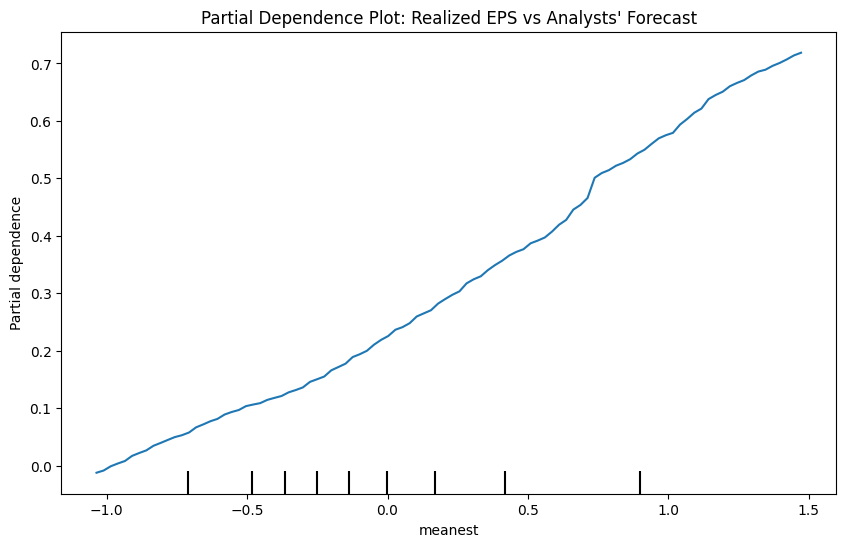

In [15]:
# Plotting using sklearn's inspection module

fig, ax = plt.subplots(figsize=(10, 6))

# Use X_scaled for plotting, but label it with the original feature name 'meanest'.
# The feature 'meanest' corresponds to the index `meanest_idx`.
# We pass X_scaled (the numpy array) to the function.
PartialDependenceDisplay.from_estimator(rf_model, X_scaled, [meanest_idx],
                                        feature_names=X.columns,
                                        ax=ax,
                                        kind='average',
                                        grid_resolution=100)

ax.set_title("Partial Dependence Plot: Realized EPS vs Analysts' Forecast")
ax.set_ylabel("Realized EPS")
ax.set_xlabel("Analysts' Forecast (Standardized)")
plt.show()

The above plot shows the standardized value of Analysts' Forecast. To interpret it in the original scale (as seen in the screenshot), we should calculate the partial dependence manually or unscale the x-axis. The screenshot shows values from -2 to 4 on the x-axis, which suggests the standardized values might be close to that range, or the raw values were centered/scaled.

If `X_scaled` was generated by `StandardScaler`, the x-axis represents Z-scores (standard deviations from the mean). The y-axis is the predicted *Realized EPS*. The shape should resemble the S-curve in your screenshot.

Calculating Partial Dependence...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    1.5s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    4.4s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:    6.3s
[Parallel(n_jobs=10)]: Done 2000 out of 2000 | elapsed:    7.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    1.5s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    2.7s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    4.2s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:    6.1s
[Parallel(n_job

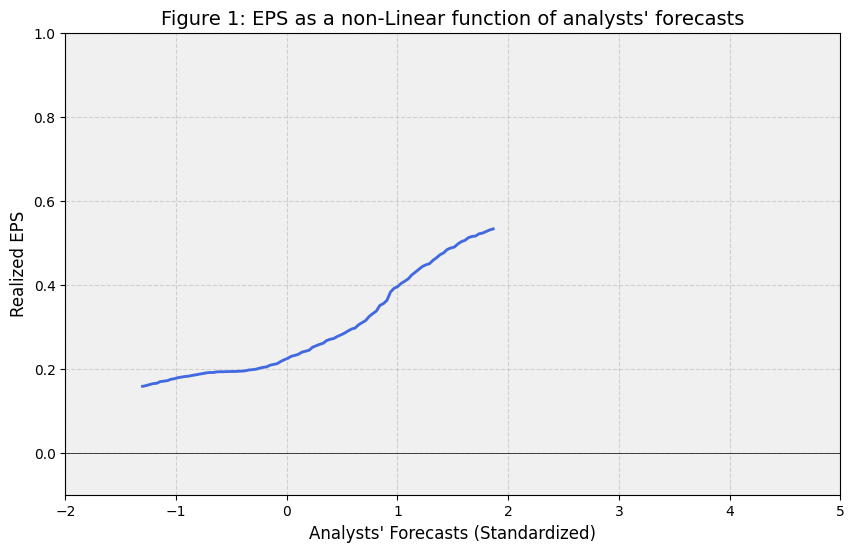

In [19]:
# ==========================================
# 3. 绘制 Partial Dependence Plot (复现风格)
# ==========================================

print("Calculating Partial Dependence...")

# 计算 PDP
pdp_results = partial_dependence(
    rf_model, 
    X_scaled, 
    [meanest_idx], 
    kind='average',
    grid_resolution=100
)

# 获取 X轴 (特征值) 和 Y轴 (预测值)
x_vals = pdp_results['grid_values'][0]
y_vals = pdp_results['average'][0]

# 注意：计算完整的 ICE 比较慢，这里为了近似效果，我们再次计算 kind='individual'
ice_results = partial_dependence(
    rf_model, 
    X_scaled, 
    [meanest_idx], 
    kind='individual',
    grid_resolution=100
)
ice_lines = ice_results['individual'][0]

# --- 修改开始 ---

# 1. 获取样本数量 N (ICE lines 的行数)
n_samples = ice_lines.shape[0]

# 2. 计算标准差 (Standard Deviation)
std_dev = np.std(ice_lines, axis=0)

# 3. 计算标准误 (Standard Error of the Mean, SEM)
# 公式: SEM = SD / sqrt(N)
sem = std_dev / np.sqrt(n_samples)

# 4. 计算 95% 置信区间 (95% Confidence Interval)
# 公式: Mean +/- 1.96 * SEM
# 原论文如果是极窄的阴影，通常就是这个，或者是 +/- 2 * SEM
margin_of_error = 1.96 * sem

upper = y_vals + margin_of_error
lower = y_vals - margin_of_error

# 开始绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 1. 画灰色阴影 (置信区间)
ax.fill_between(x_vals, lower, upper, color='grey', alpha=0.3, label='Confidence Interval')

# 2. 画蓝色主曲线
ax.plot(x_vals, y_vals, color='royalblue', linewidth=2, label='Partial Dependence')

# 3. 添加参考线 (y=0)
ax.axhline(0, color='black', linewidth=0.5)

# 4. 设置坐标轴范围 (参考论文 Figure 1)
# 论文 X轴大约是 -2 到 5
ax.set_xlim(-2, 5)
# 论文 Y轴大约是 -0.1 到 0.9 (根据你的数据实际情况调整)
ax.set_ylim(-0.1, 1.0)

# 5. 标签和标题
ax.set_title("Figure 1: EPS as a non-Linear function of analysts' forecasts", fontsize=14)
ax.set_xlabel("Analysts' Forecasts (Standardized)", fontsize=12)
ax.set_ylabel("Realized EPS", fontsize=12)

# 设置背景网格风格
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('#f0f0f0') # 模仿论文的浅灰背景

plt.show()

Calculating Partial Dependence...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    1.6s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    4.4s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:    6.3s
[Parallel(n_jobs=10)]: Done 2000 out of 2000 | elapsed:    7.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    1.5s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    4.4s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:    6.3s
[Parallel(n_job

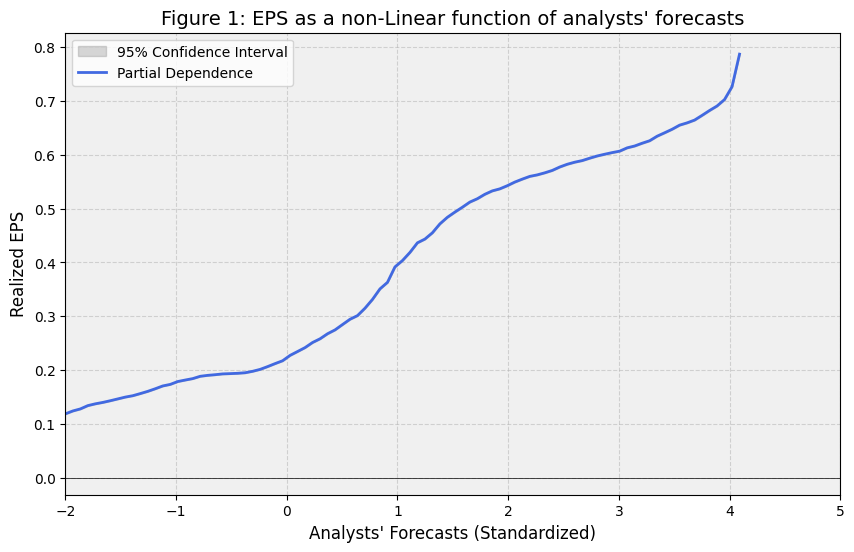

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import partial_dependence

# ... (假设 rf_model, X_scaled, meanest_idx 已经定义好) ...

# ==========================================
# 3. 绘制 Partial Dependence Plot (复现风格)
# ==========================================

print("Calculating Partial Dependence...")

# -----------------------------------------------------------
# 修改点 1: 确保计算范围覆盖你想要的 X 轴区域
# -----------------------------------------------------------
# percentiles=(0, 1) 表示计算数据中最小值到最大值的范围。
# 如果你需要更宽的范围（例如推断），或者数据中有极值导致范围太大，
# 可以调整这里。通常保持 (0, 1) 是最安全的。
calc_percentiles = (0, 1) 

# 计算 PDP
pdp_results = partial_dependence(
    rf_model, 
    X_scaled, 
    [meanest_idx], 
    kind='average',
    grid_resolution=100,
    percentiles=calc_percentiles
)

# 获取 X轴 (特征值) 和 Y轴 (预测值)
x_vals = pdp_results['grid_values'][0]
y_vals = pdp_results['average'][0]

# 计算 ICE 用于置信区间
ice_results = partial_dependence(
    rf_model, 
    X_scaled, 
    [meanest_idx], 
    kind='individual',
    grid_resolution=100,
    percentiles=calc_percentiles
)
ice_lines = ice_results['individual'][0]

# --- 统计计算 (保持不变) ---
n_samples = ice_lines.shape[0]
std_dev = np.std(ice_lines, axis=0)
sem = std_dev / np.sqrt(n_samples)
margin_of_error = 1.96 * sem
upper = y_vals + margin_of_error
lower = y_vals - margin_of_error

# --- 开始绘图 ---
fig, ax = plt.subplots(figsize=(10, 6))

# 1. 画灰色阴影 (置信区间)
ax.fill_between(x_vals, lower, upper, color='grey', alpha=0.3, label='95% Confidence Interval')

# 2. 画蓝色主曲线
ax.plot(x_vals, y_vals, color='royalblue', linewidth=2, label='Partial Dependence')

# 3. 添加参考线 (y=0)
ax.axhline(0, color='black', linewidth=0.5)

# -----------------------------------------------------------
# 修改点 2: 设置 X 轴显示范围
# -----------------------------------------------------------
# 这里的数值决定了图表横坐标的左右边界。
# 方案 A: 手动指定 (例如论文中的范围)
target_xlim = (-2, 5) 

# 方案 B: 自动适应数据范围 (如果你不知道具体数值)
# target_xlim = (x_vals.min(), x_vals.max())

ax.set_xlim(target_xlim)

# -----------------------------------------------------------
# 可选修改: 设置 Y 轴显示范围
# -----------------------------------------------------------
# 如果修改 X 轴后发现曲线跑出去了，或者留白太多，可以调整 Y 轴
# ax.set_ylim(-0.1, 1.0) 

# 5. 标签和标题
ax.set_title("Figure 1: EPS as a non-Linear function of analysts' forecasts", fontsize=14)
ax.set_xlabel("Analysts' Forecasts (Standardized)", fontsize=12)
ax.set_ylabel("Realized EPS", fontsize=12)
ax.legend(loc='upper left')

# 设置背景网格风格
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('#f0f0f0') 

plt.show()